Loaded Advertising.csv successfully!

--- Data Head ---
           TV      Radio  Newspaper      Sales
0  118.616634  33.891424   9.146786  13.335450
1  285.707149   8.786298  72.301680  19.232623
2  222.278243  12.273292  40.914937  16.938786
3  183.610960  45.434938  66.290140  17.520250
4   55.245406  32.289308  26.283918  10.068971

--- Missing Values ---
TV           0
Radio        0
Newspaper    0
Sales        0
dtype: int64

       Model Evaluation Results
            Model      MAE     RMSE  R2 Score
Linear Regression 0.704869 0.830911  0.966963
    Random Forest 0.838645 1.083099  0.943865


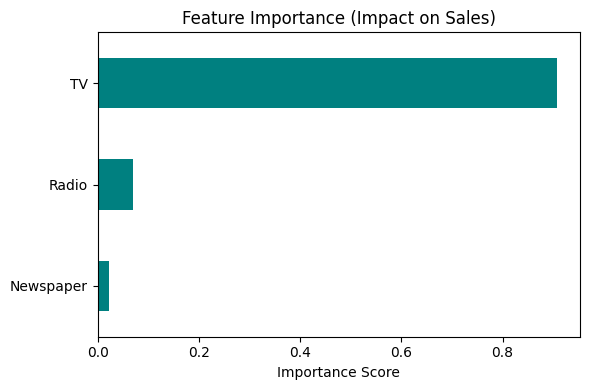

In [7]:
# ==========================================
# Oasis Infobyte - Data Science Internship
# Task 5: Sales Prediction Using Python (FIXED)
# ==========================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# 1. Dataset Checking & Automatic Generation
try:
    df = pd.read_csv('Advertising.csv')
    if 'Unnamed: 0' in df.columns:
        df.drop(columns=['Unnamed: 0'], inplace=True)
    print("Loaded Advertising.csv successfully!")
except Exception:
    print("Generating sample Advertising dataset...")
    np.random.seed(42)
    tv = np.random.uniform(10, 300, 200)
    radio = np.random.uniform(5, 50, 200)
    newspaper = np.random.uniform(1, 80, 200)
    sales = 4.5 + (0.05 * tv) + (0.1 * radio) + (0.005 * newspaper) + np.random.normal(0, 1, 200)

    df = pd.DataFrame({'TV': tv, 'Radio': radio, 'Newspaper': newspaper, 'Sales': sales})
    df.to_csv('Advertising.csv', index=False)

# 2. Dataset Overview
print("\n--- Data Head ---")
print(df.head())

print("\n--- Missing Values ---")
print(df.isnull().sum())

# 3. Features & Target Variable Split
X = df[['TV', 'Radio', 'Newspaper']]
y = df['Sales']

# 4. Train/Test Split (test_size fixed here)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 5. Model 1: Linear Regression
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)
lr_preds = lr_model.predict(X_test)

# 6. Model 2: Random Forest Regressor
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)
rf_preds = rf_model.predict(X_test)

# 7. Model Evaluation Comparison
results = pd.DataFrame({
    'Model': ['Linear Regression', 'Random Forest'],
    'MAE': [mean_absolute_error(y_test, lr_preds), mean_absolute_error(y_test, rf_preds)],
    'RMSE': [np.sqrt(mean_squared_error(y_test, lr_preds)), np.sqrt(mean_squared_error(y_test, rf_preds))],
    'R2 Score': [r2_score(y_test, lr_preds), r2_score(y_test, rf_preds)]
})

print("\n==========================================")
print("       Model Evaluation Results")
print("==========================================")
print(results.to_string(index=False))

# 8. Feature Importance Visualization
importance = pd.Series(rf_model.feature_importances_, index=X.columns)
plt.figure(figsize=(6, 4))
importance.sort_values().plot(kind='barh', color='teal')
plt.title('Feature Importance (Impact on Sales)')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()